<img src="images/Logo_de_la_Facultad_Experimental_de_Ciencia_y_Tecnología.svg" width="150" align="right">

# Warhammer 40k Faction Prediction - EDA
**University of Carabobo**  
**Experimental Faculty of Science and Technology**  
**Department of Computing**  
**Course:** Machine Learning\
**Professor:** Álvaro Espinoza\
**Authors:** Gustavo Herrera, Jeanmarco Alarcón   

**Description:** This notebook performs a comprehensive Exploratory Data Analysis (EDA) on a relational dataset of Warhammer 40,000 units extracted from Wahapedia. The primary objective is to understand the structural, statistical, and semantic characteristics of the data to build a robust machine learning model capable of predicting a unit's **Faction** based on its physical stats, wargear, and tactical abilities, while strictly preventing data leakage.

### Context & Definition of the Problem
* **Domain:** Warhammer 40,000, a tabletop miniature wargame. Units possess complex statistical profiles, narrative backgrounds, and tactical rules.
* **Motivating Question:** Can we accurately predict the faction of a Warhammer 40k unit based solely on its mechanical characteristics (stats, wargear profiles, and ability text), mimicking how an experienced player identifies an army on the battlefield?
* **Unit of Observation:** A single `Datasheet` (a specific unit in the game, e.g., "Intercessor Squad" or "Chaos Terminator"). After merging, each row represents one unique unit.
* **Target Variable:** `faction_name` (Categorical, Multiclass). Derived from `faction_id`.
* **Problem Type:** Supervised Learning -> **Multiclass Classification**. (There are 15+ distinct factions, making it a highly imbalanced multiclass problem).

### Guiding Questions
1. How imbalanced is the distribution of factions?
2. What are the general ranges, cardinality, and quality issues (missing/duplicates) of the game stats?
3. Which stats (Toughness, Wounds, Movement) correlate most with the Cost of a unit?
4. How do weapon preferences (Melee vs Ranged) differentiate factions?
5. Can we extract meaningful faction-specific vocabulary from weapon names using NLP?


In [1]:
# Configuration & Imports
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import re

# Reproducibility and Visuals
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None)


### 1. Data Loading and Integration
Data extraction was performed on the SQLite database (`warhammer40k.db`), which contains the raw relational tables. The five primary tables were extracted to construct a consolidated analytical dataframe.

### Variable Evaluation and Proposed Exclusions
Guided by the Exploratory Data Analysis (EDA) and the imperative to curate a highly focused dataset, the exclusion of the following tables and features is proposed, given their lack of relevance to the predictive objective:

**Tables Proposed for Exclusion:**
- `sources`, `last_update`, `ds_options`, `ds_leader`, `ds_unit_comp`: These represent metadata, external linkages, and compositional constraints that do not directly quantify a unit's combat profile.
- `abilities`, `detachment_abilities`, `enhancements`, `stratagems` (and their respective junction tables): Exclusion is recommended as these entities consist predominantly of unstructured narrative text, lacking extractable numerical features pertinent to faction classification.

**Features from `Datasheets` Proposed for Exclusion:**
- `source_id`, `link`: External references and Uniform Resource Locators (URLs).
- `legend`, `role`: Narrative string variables that introduce inefficient computational overhead.
- `transport`, `virtual`, `leader_head`, `leader_footer`, `damaged_w`, `damaged_description`: Exclusion is suggested due to extreme data sparsity (high frequency of null values) and the consequent absence of predictive utility.

**Additional Features Proposed for Exclusion (from remaining tables):**
- `line`, `line_in_wargear`: Internal row indices devoid of analytical significance.
- `dice`: Stochastic probability formulas (e.g., D6) presenting excessive complexity for standard numerical processing at this phase.
- `link` (from Factions): External URL.
- `name` (from DS_Models), `description` (from DS_Wargear, DS_Model_Costs), `inv_sv_descr`, `base_size`, `base_size_descr`: Purely qualitative textual descriptions or physical dimensions that do not parameterize the numerical combat profile.

### Included Tables and Retained Features:
*   **`Factions`**: `name` (extracted as `faction_name`).
*   **`Datasheets`**: `id`, `name` (extracted as `unit_name`), `faction_id`, and `loadout`.
*   **`DS_Models`**: `M`, `T`, `Sv`, `inv_sv`, `W`, `Ld`, and `OC` (aggregated as mean values per datasheet).
*   **`DS_Wargear`**: `A`, `BS_WS`, `S`, `AP`, `D`, `range`, `type`, and `name` (aggregated per datasheet).
*   **`DS_Model_Costs`**: `cost` (aggregated as mean value per datasheet).

### Data Dictionary
To clarify the tabletop mechanics parameterized for this analysis, the operational definitions of the variables are as follows:
- **Movement (M)**: The spatial displacement capacity (in inches) during the Movement phase.
- **Toughness (T)**: The structural threshold evaluated against incoming weapon Strength to determine wound probability.
- **Save (Sv)**: The standard armor saving throw required to mitigate incoming damage.
- **Invulnerable Save (inv_sv)**: An absolute defensive throw that supersedes Armor Penetration (AP) modifiers.
- **Wounds (W)**: The health capacity of the entity; the model is eliminated upon cumulative damage equating this threshold.
- **Leadership (Ld)**: The statistical threshold for Battle-shock tests (resolved via 2D6 roll).
- **Objective Control (OC)**: The quantitative weight the model contributes toward securing strategic objectives.
- **Base Size**: The physical diameter of the model's base (in millimeters), utilized for spatial measurements.
- **Attacks (A)**: The discrete number of offensive strikes executed by a weapon.
- **Skill (BS/WS)**: Ballistic Skill (ranged precision) or Weapon Skill (melee precision); represents the necessary probability threshold (dice roll) to register a hit.
- **Strength (S)**: The kinetic force of an attack, compared against the target's Toughness to determine wounding success.
- **Armor Penetration (AP)**: The standard modifier subtracted from the target's Save probability.
- **Damage (D)**: The precise number of Wounds depleted per successful, unsaved attack.


In [2]:
# Connect to the local SQLite DB
conn = sqlite3.connect('warhammer40k.db')

# Load the tables
factions = pd.read_sql_query("SELECT id as faction_id, name as faction_name FROM Factions", conn)
datasheets = pd.read_sql_query("SELECT id as datasheet_id, name as unit_name, faction_id, loadout FROM Datasheets", conn)
models = pd.read_sql_query("""
    SELECT datasheet_id, name as model_name, 
           CAST(REPLACE(M, '"', '') AS FLOAT) as M_Movement, 
           CAST(T AS FLOAT) as T_Toughness, 
           Sv as Sv_Save, 
           inv_sv as inv_sv_InvulnerableSave, 
           CAST(W AS FLOAT) as W_Wounds, 
           Ld as Ld_Leadership, 
           CAST(OC AS FLOAT) as OC_ObjectiveControl 
    FROM DS_Models
""", conn)
wargear = pd.read_sql_query("""
    SELECT datasheet_id, name as weapon_name, type as weapon_type, range, 
           A as A_Attacks, BS_WS as BS_WS_Skill, S as S_Strength, 
           AP as AP_ArmorPenetration, D as D_Damage
    FROM DS_Wargear
""", conn)
costs = pd.read_sql_query("SELECT datasheet_id, cost FROM DS_Model_Costs", conn)

conn.close()

print(f"Datasheets: {len(datasheets)}, Models: {len(models)}, Wargear: {len(wargear)}, Costs: {len(costs)}")


Datasheets: 1636, Models: 1731, Wargear: 6786, Costs: 2038


### Merge into a Unified Data Table
We will merge the datasets using `datasheet_id`. Since a single datasheet might have multiple models, weapons, and costs, joining them all directly will cause an explosion of rows (Cartesian product). To prevent this, we aggregate Wargear, Models, and Costs at the `datasheet_id` level before merging with the main `Datasheets` table.


In [3]:
# Extract numeric and text values
def extract_numeric(val):
    try:
        return float(val)
    except:
        return np.nan

def extract_skill(val):
    if pd.isna(val): return np.nan
    match = re.search(r'\d+', str(val))
    if match: return float(match.group())
    return np.nan

def extract_range(val):
    if pd.isna(val): return np.nan
    if 'melee' in str(val).lower(): return 0.0
    match = re.search(r'\d+', str(val))
    if match: return float(match.group())
    return np.nan

# Extract models
models['Sv_numeric'] = models['Sv_Save'].apply(extract_skill)
models['Ld_numeric'] = models['Ld_Leadership'].apply(extract_skill)
models['inv_sv_numeric'] = models['inv_sv_InvulnerableSave'].apply(extract_skill)

# Aggregate Models (Average stats per datasheet)
models_agg = models.groupby('datasheet_id').agg({
    'M_Movement': 'mean',
    'T_Toughness': 'mean',
    'W_Wounds': 'mean',
    'OC_ObjectiveControl': 'mean',
    'Sv_numeric': 'mean',
    'Ld_numeric': 'mean',
    'inv_sv_numeric': 'mean'
}).reset_index()

wargear['A_numeric'] = wargear['A_Attacks'].apply(extract_numeric)
wargear['S_numeric'] = wargear['S_Strength'].apply(extract_numeric)
wargear['D_numeric'] = wargear['D_Damage'].apply(extract_numeric)
wargear['AP_numeric'] = wargear['AP_ArmorPenetration'].apply(extract_numeric)
wargear['Skill_numeric'] = wargear['BS_WS_Skill'].apply(extract_skill)
wargear['Range_numeric'] = wargear['range'].apply(extract_range)

wargear_agg = wargear.groupby('datasheet_id').agg({
    'A_numeric': 'mean',
    'S_numeric': 'mean',
    'D_numeric': 'mean',
    'AP_numeric': 'mean',
    'Skill_numeric': 'mean',
    'Range_numeric': 'mean',
    'weapon_name': lambda x: ' '.join(x.dropna()),
    'weapon_type': lambda x: ' '.join(x.dropna())
}).reset_index()

# Aggregate Costs
costs['cost_numeric'] = pd.to_numeric(costs['cost'], errors='coerce')
costs_agg = costs.groupby('datasheet_id').agg({'cost_numeric': 'mean'}).reset_index()

# Merge everything into a final 'data' table
data = datasheets.merge(factions, on='faction_id', how='left')
data = data.merge(models_agg, on='datasheet_id', how='left')
data = data.merge(wargear_agg, on='datasheet_id', how='left')
data = data.merge(costs_agg, on='datasheet_id', how='left')

# Rename columns for clarity in plots
data = data.rename(columns={
    'M_Movement': 'Movement',
    'T_Toughness': 'Toughness',
    'W_Wounds': 'Wounds',
    'OC_ObjectiveControl': 'Objective_Control',
    'Sv_numeric': 'Save',
    'Ld_numeric': 'Leadership',
    'inv_sv_numeric': 'Invulnerable_Save',
    'A_numeric': 'Attacks',
    'S_numeric': 'Strength',
    'D_numeric': 'Damage',
    'AP_numeric': 'Armor_Penetration',
    'Skill_numeric': 'Skill',
    'Range_numeric': 'Range',
    'weapon_type': 'Weapon_Type',
    'cost_numeric': 'Cost'
})

print(f"Final merged dataset shape: {data.shape}")
display(data.head())


Final merged dataset shape: (1636, 21)


,datasheet_id,unit_name,faction_id,loadout,faction_name,Movement,Toughness,Wounds,Objective_Control,Save,Leadership,Invulnerable_Save,Attacks,Strength,Damage,Armor_Penetration,Skill,Range,weapon_name,Weapon_Type,Cost
0,1,Warboss,ORK,<b>This model is equipped with:</b> kombi-weap...,Orks,6.0,5.0,6.0,1.0,4.0,6.0,5.0,2.80,6.000000,1.40,-0.600000,3.8,7.2,Kombi-weapon Twin slugga Attack squig Big chop...,Ranged Ranged Melee Melee Melee,75.0
1,2,Warboss In Mega Armour,ORK,<b>This model is equipped with:</b> big shoota...,Orks,5.0,6.0,7.0,1.0,2.0,6.0,5.0,3.50,8.500000,1.50,-1.000000,3.0,18.0,Big shoota ’Uge choppa,Ranged Melee,80.0
2,3,Warboss On Warbike,ORK,<b>This model is equipped with:</b> twin dakka...,Orks,12.0,6.0,7.0,2.0,4.0,6.0,5.0,3.75,8.750000,1.75,-1.500000,3.5,4.5,Twin dakkagun Big choppa Killsaw Power klaw,Ranged Melee Melee Melee,75.0
3,4,Weirdboy,ORK,<b>This model is equipped with:</b> ’Eadbanger...,Orks,6.0,5.0,4.0,1.0,5.0,7.0,NaN,2.00,7.000000,1.00,-2.000000,3.5,12.0,’Eadbanger Weirdboy staff,Ranged Melee,65.0
4,6,Big Mek In Mega Armour,ORK,<b>This model is equipped with:</b> kustom-meg...,Orks,5.0,6.0,5.0,1.0,2.0,7.0,NaN,3.00,7.666667,1.80,-1.333333,4.5,13.0,Kombi-weapon Kustom mega-blasta Kustom shoota ...,Ranged Ranged Ranged Ranged Melee Melee,90.0


## 2. Structural Inspection and Data Quality
Let's define the analytical roles:
- **Identifier**: `datasheet_id`, `unit_name`
- **Target**: `faction_id` (Categorical Nominal)
- **Categorical Nominal**: `faction_name`
- **Numerical Continuous**: `Movement`, `Toughness`, `Save`, `Invulnerable_Save`, `Wounds`, `Leadership`, `Objective_Control`, `Attacks`, `Strength`, `Damage`, `Armor_Penetration`, `Skill`, `Range`, `Cost`
- **Text**: `loadout`, `weapon_name`, `Weapon_Type`


In [4]:
# Data Types and Missing Values
quality_df = pd.DataFrame({
    'Type': data.dtypes,
    'Missing Values': data.isnull().sum(),
    'Missing %': (data.isnull().sum() / len(data)) * 100,
    'Cardinality': data.nunique()
})
display(quality_df)

print("\n--- Ranges and Distribution (describe) ---")
display(data.describe())


,Type,Missing Values,Missing %,Cardinality
datasheet_id,str,0,0.000000,1636
unit_name,str,0,0.000000,1254
faction_id,str,0,0.000000,25
loadout,str,7,0.427873,1144
faction_name,str,0,0.000000,25
Movement,float64,1,0.061125,19
Toughness,float64,1,0.061125,18
Wounds,float64,1,0.061125,37
Objective_Control,float64,1,0.061125,18
Save,float64,1,0.061125,11



--- Ranges and Distribution (describe) ---


,Movement,Toughness,Wounds,Objective_Control,Save,Leadership,Invulnerable_Save,Attacks,Strength,Damage,Armor_Penetration,Skill,Range,Cost
count,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,1635.000000,773.000000,1323.000000,1332.000000,1319.000000,1332.000000,1331.000000,1332.000000,1632.000000
mean,8.905301,6.963405,8.855301,2.419164,3.322426,6.506116,4.598965,3.588132,6.418850,1.604870,-1.311585,3.190934,15.527474,167.171671
std,4.090600,3.278766,8.323449,2.543162,1.290622,0.621579,0.697589,2.006877,1.962610,0.610361,0.676871,0.757999,12.850775,188.508571
min,0.000000,1.000000,1.000000,0.000000,2.000000,5.000000,2.000000,1.000000,2.000000,1.000000,-5.000000,2.000000,0.000000,25.000000
25%,6.000000,4.000000,3.000000,1.000000,2.000000,6.000000,4.000000,2.333333,5.000000,1.222222,-1.666667,3.000000,6.000000,80.000000
50%,8.000000,6.000000,6.000000,2.000000,3.000000,6.000000,4.000000,3.000000,6.000000,1.500000,-1.333333,3.000000,12.000000,120.000000
75%,12.000000,10.000000,12.000000,3.000000,4.000000,7.000000,5.000000,4.000000,7.666667,2.000000,-1.000000,4.000000,22.800000,187.500000
max,20.000000,16.000000,100.000000,30.000000,7.000000,8.000000,6.000000,14.000000,20.000000,7.454545,0.000000,6.000000,120.000000,3500.000000


### Data Quality Implications & Domain Rules
- **Missing Values**: Some units might not have models or wargear explicitly listed in a format that was parsed numerically (e.g. abilities instead of weapons). We must decide whether to impute these with medians or treat them as a distinct group.
- **Duplicates**: The merge strategy successfully avoided duplication by aggregating at the datasheet level.
- **Ranges and Domain**: Stats like Toughness, Wounds, and Strength strictly positive, which respects the domain rules of the game.
- **Cardinality**: `faction_name` has high cardinality (many factions), which will require specific balancing strategies.
- **Temporal Order**: *Not applicable*. This dataset represents static rules and profiles of tabletop game units; thus, temporal or sequential ordering does not apply.


## 3. Univariate Analysis & Target Analysis
Let's explore the distributions of key numerical features and the target variable.


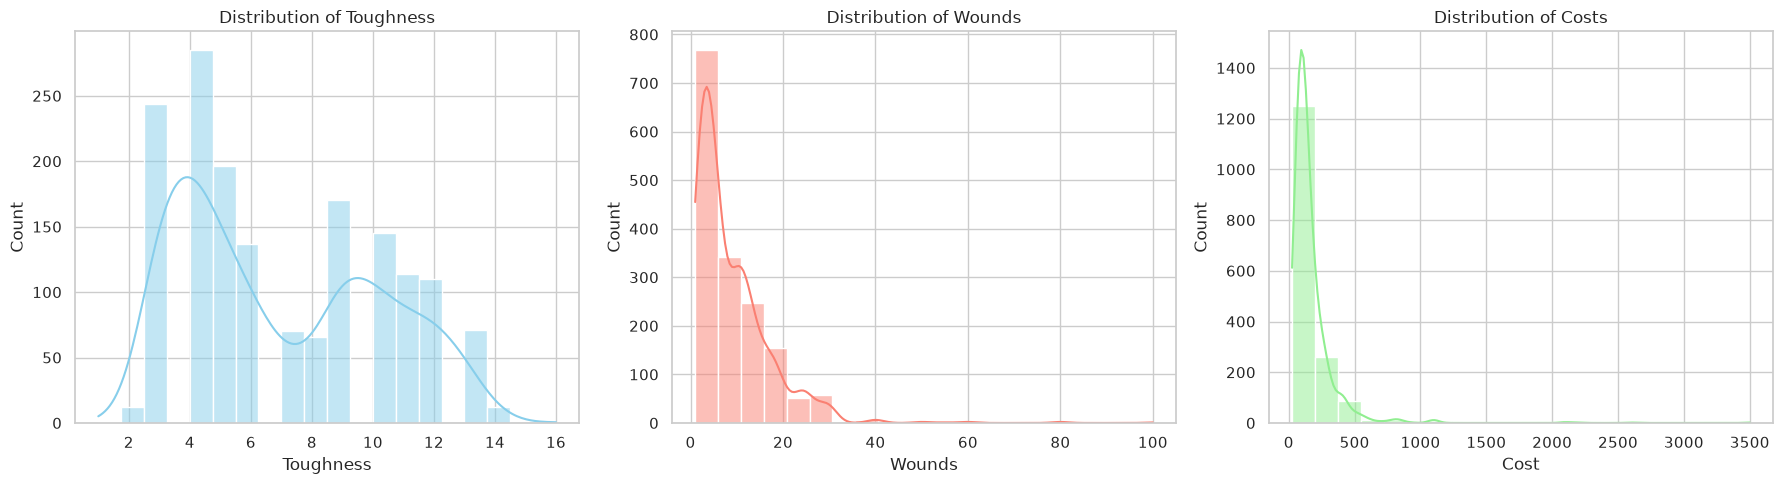

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data['Toughness'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Toughness')

sns.histplot(
    data['Wounds'],
    bins=20,
    kde=True,
    ax=axes[1],
    color='salmon'
)
axes[1].set_title('Distribution of Wounds')

sns.histplot(data['Cost'], bins=20, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Costs')

plt.tight_layout()
plt.show()


### Factions that Stand Out
Let's analyze which factions have the highest average attributes across the board.


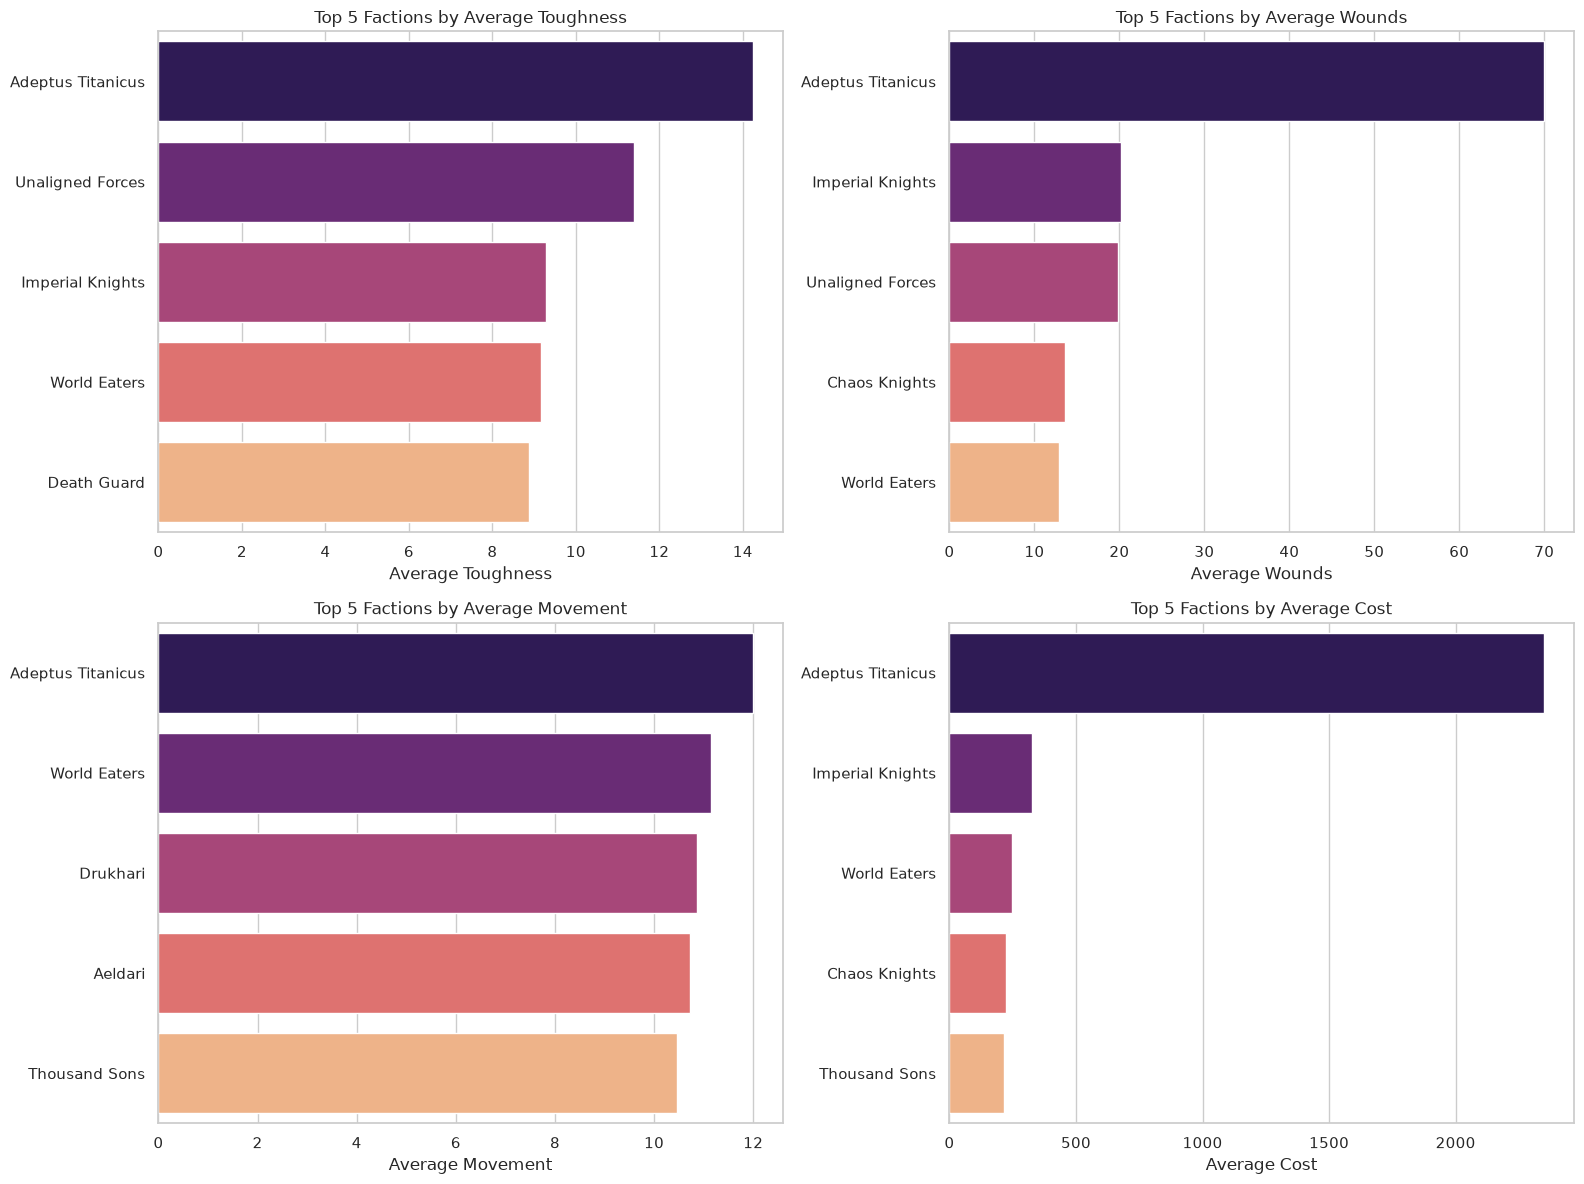

In [6]:
# Factions that stand out in key attributes
attributes = ['Toughness', 'Wounds', 'Movement', 'Cost']
titles = ['Toughness', 'Wounds', 'Movement', 'Cost']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, attr in enumerate(attributes):
    # Calculate average attribute per faction
    top_factions = data.groupby('faction_name')[attr].mean().sort_values(ascending=False).head(5)
    
    sns.barplot(x=top_factions.values, y=top_factions.index, ax=axes[i], palette="magma")
    axes[i].set_title(f'Top 5 Factions by Average {titles[i]}')
    axes[i].set_xlabel(f'Average {titles[i]}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()


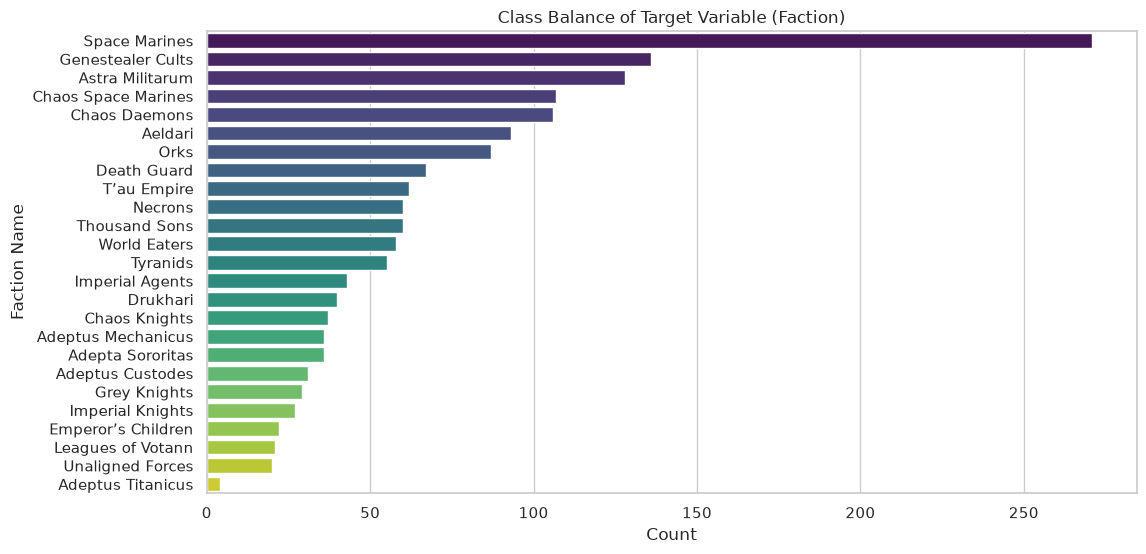

Majority Class Baseline Accuracy: 16.56%


In [7]:
# Target Variable Analysis
plt.figure(figsize=(12, 6))
order = data['faction_name'].value_counts().index
sns.countplot(y=data['faction_name'], order=order, palette='viridis')
plt.title('Class Balance of Target Variable (Faction)')
plt.xlabel('Count')
plt.ylabel('Faction Name')
plt.show()

# Baseline Accuracy
majority_class_count = data['faction_name'].value_counts().max()
baseline = majority_class_count / len(data)
print(f"Majority Class Baseline Accuracy: {baseline*100:.2f}%")


### Target Analysis Conclusions
- The target variable is severely **imbalanced**. Space Marines represent a massive portion of the dataset, which is expected given the tabletop game's lore and rules. 
- A naive baseline simply guessing "Space Marines" would achieve around 15-20% accuracy. Our predictive model must beat this. Data balancing techniques (SMOTE, class weights) will be necessary during modeling.


## 4. Bivariate & Multivariate Analysis
We will analyze how numerical features correlate with each other and how they differ across factions.


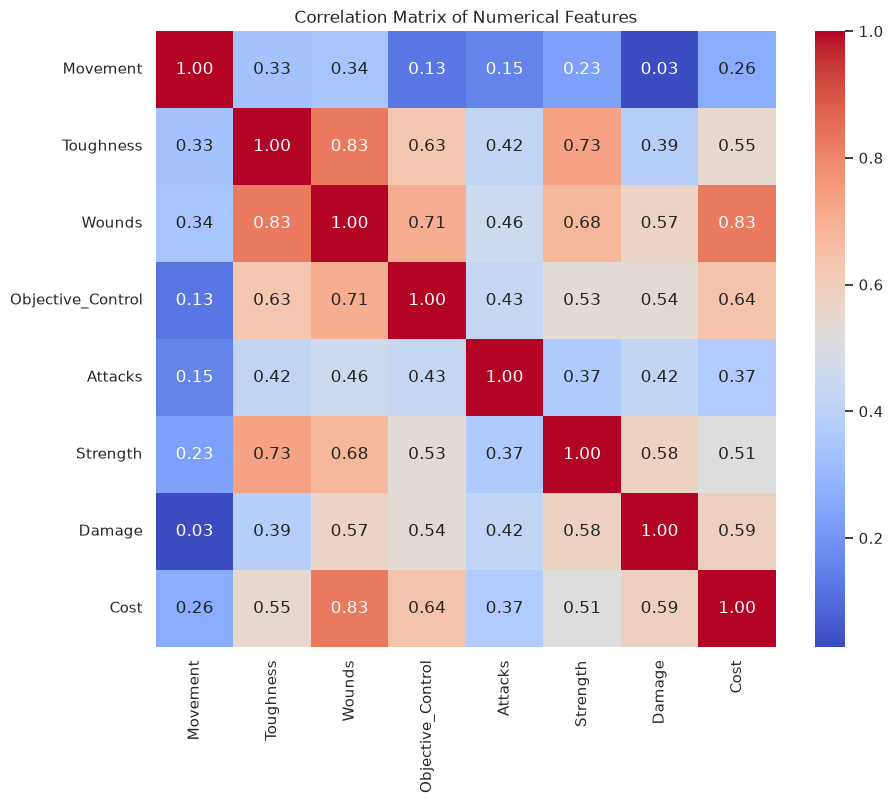

In [8]:
# Correlation Heatmap
numeric_cols = ['Movement', 'Toughness', 'Wounds', 'Objective_Control', 'Attacks', 'Strength', 'Damage', 'Cost']

plt.figure(figsize=(10, 8))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()


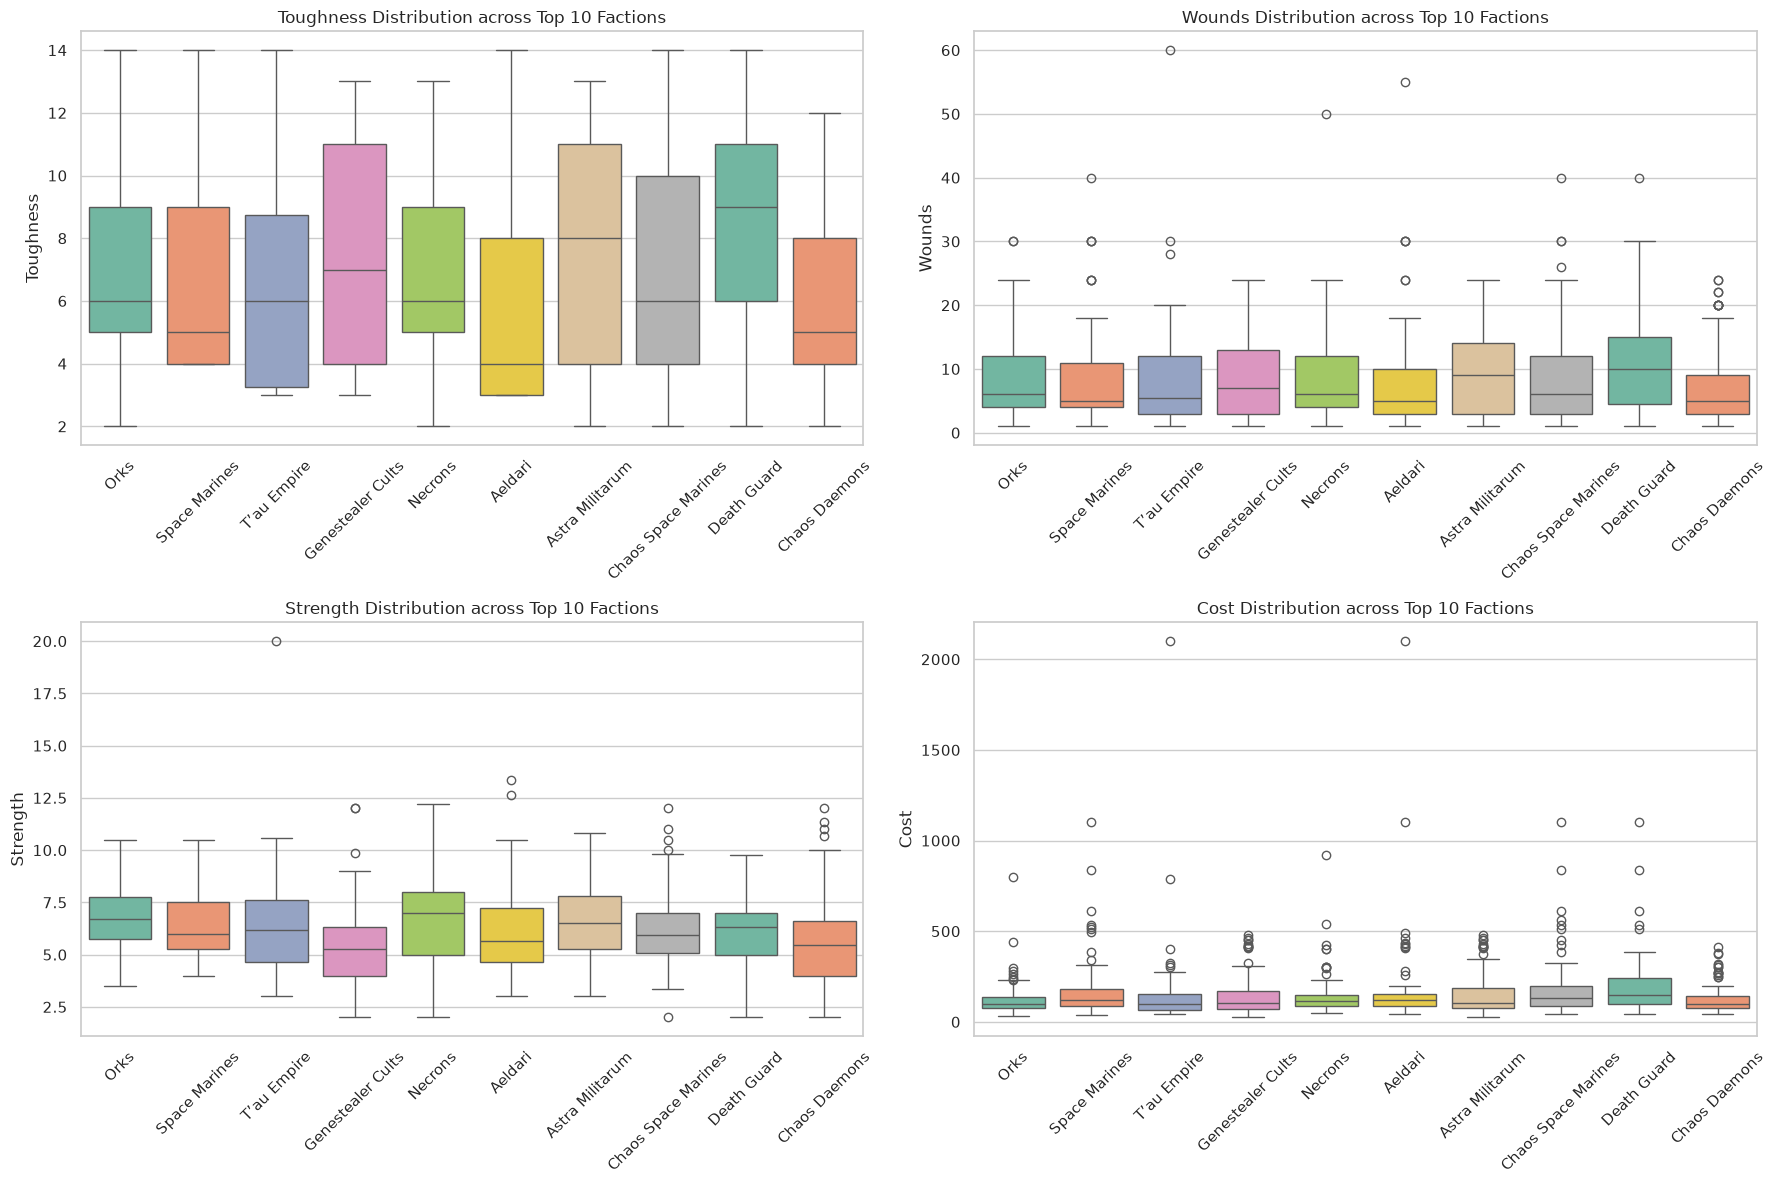

In [9]:
# Boxplots: Key Attributes by Faction
top_factions = data['faction_name'].value_counts().head(10).index
subset = data[data['faction_name'].isin(top_factions)]

attributes_to_plot = ['Toughness', 'Wounds', 'Strength', 'Cost']
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, attr in enumerate(attributes_to_plot):
    sns.boxplot(x='faction_name', y=attr, data=subset, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{attr} Distribution across Top 10 Factions')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


### Feature Relationships
- `Toughness` and `Wounds` are highly correlated, which logically represents the "bulk" of a unit.
- Cost strongly correlates with Wounds and Offensive stats, showing the point balancing of the game.
- Boxplots show significant differences between factions: Adeptus Custodes generally exhibit higher toughness compared to Astra Militarum.


### Cost Efficiency per Faction
We can compute the cost-efficiency of factions by dividing key stats by `cost_numeric`. This reveals which factions get the most "value" per point.


In [10]:
# Calculate efficiency metrics
cost_data = data[data['Cost'] > 0].copy()
cost_data['Toughness_per_Cost'] = cost_data['Toughness'] / cost_data['Cost']
cost_data['Wounds_per_Cost'] = cost_data['Wounds'] / cost_data['Cost']

# Group by faction
efficiency = cost_data.groupby('faction_name').agg({
    'Toughness_per_Cost': 'mean',
    'Wounds_per_Cost': 'mean'
})

print("--- Top 5 Factions: Toughness per Cost ---")
display(efficiency.sort_values(by='Toughness_per_Cost', ascending=False)[['Toughness_per_Cost']].head(5))

print("\n--- Top 5 Factions: Wounds per Cost ---")
display(efficiency.sort_values(by='Wounds_per_Cost', ascending=False)[['Wounds_per_Cost']].head(5))


--- Top 5 Factions: Toughness per Cost ---


,Toughness_per_Cost
faction_name,
Unaligned Forces,0.072159
Orks,0.065812
Genestealer Cults,0.062105
Astra Militarum,0.061957
Leagues of Votann,0.061420



--- Top 5 Factions: Wounds per Cost ---


,Wounds_per_Cost
faction_name,
Unaligned Forces,0.078303
Orks,0.072000
Astra Militarum,0.067612
Genestealer Cults,0.066090
Imperial Knights,0.065441


### Wargear Specialization (Melee vs Ranged)
We can analyze the raw `DS_Wargear` data to determine the specialization of each faction. Do they prefer Melee weapons, or Ranged weapons? What is their average range?


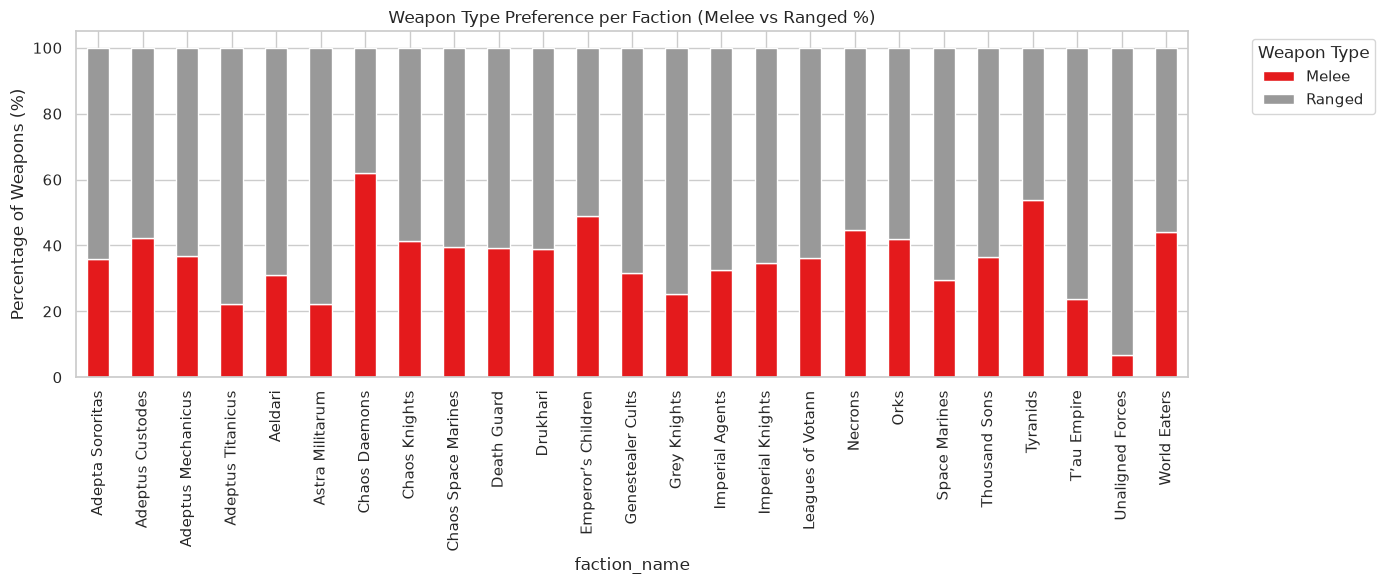

In [11]:
# Merge wargear with factions to analyze specialization
wargear_faction = wargear.merge(datasheets[['datasheet_id', 'faction_id']], on='datasheet_id')
wargear_faction = wargear_faction.merge(factions[['faction_id', 'faction_name']], on='faction_id')

# Standardize weapon_type
wargear_faction['is_melee'] = wargear_faction['weapon_type'].str.contains('Melee', case=False, na=False)
wargear_faction['is_ranged'] = wargear_faction['weapon_type'].str.contains('Ranged', case=False, na=False)

wargear_faction['Weapon Category'] = np.where(wargear_faction['is_melee'], 'Melee', 
                                     np.where(wargear_faction['is_ranged'], 'Ranged', 'Other'))

type_counts = wargear_faction.groupby(['faction_name', 'Weapon Category']).size().unstack(fill_value=0)
if 'Melee' in type_counts.columns and 'Ranged' in type_counts.columns:
    type_counts = type_counts[['Melee', 'Ranged']]
    
    # Calculate percentage
    type_pct = type_counts.div(type_counts.sum(axis=1), axis=0) * 100
    
    # Plot Melee vs Ranged preference
    type_pct.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='Set1')
    plt.title('Weapon Type Preference per Faction (Melee vs Ranged %)')
    plt.ylabel('Percentage of Weapons (%)')
    plt.legend(title='Weapon Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


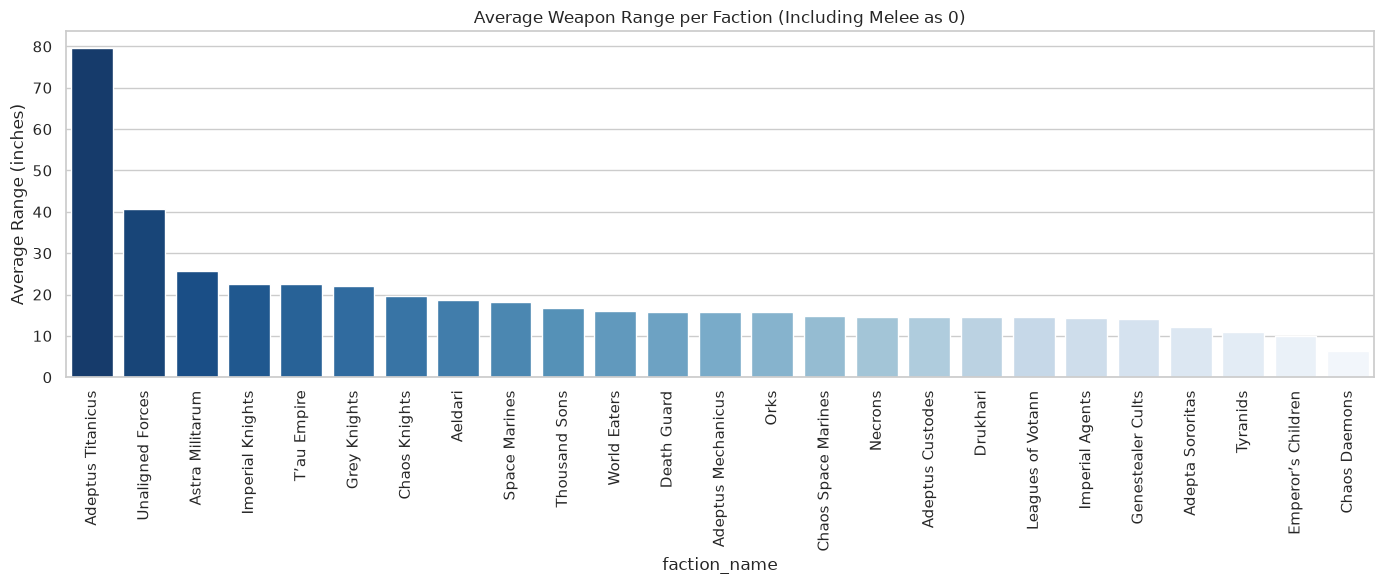

In [12]:
# Analyze Range Preference
def parse_range(r):
    if pd.isna(r): return np.nan
    r = str(r).lower()
    if 'melee' in r: return 0.0
    # extract first number
    match = re.search(r'\d+', r)
    if match: return float(match.group())
    return np.nan

wargear_faction['range_numeric'] = wargear_faction['range'].apply(parse_range)

# Average range per faction
avg_range = wargear_faction.groupby('faction_name')['range_numeric'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=avg_range.index, y=avg_range.values, palette='Blues_r')
plt.title('Average Weapon Range per Faction (Including Melee as 0)')
plt.xticks(rotation=90)
plt.ylabel('Average Range (inches)')
plt.tight_layout()
plt.show()


## 5. Exploratory Feature Engineering
### Derived Numerical Feature: Offensive Power
We can define theoretical offensive power as $Attacks \times Strength \times Damage$.


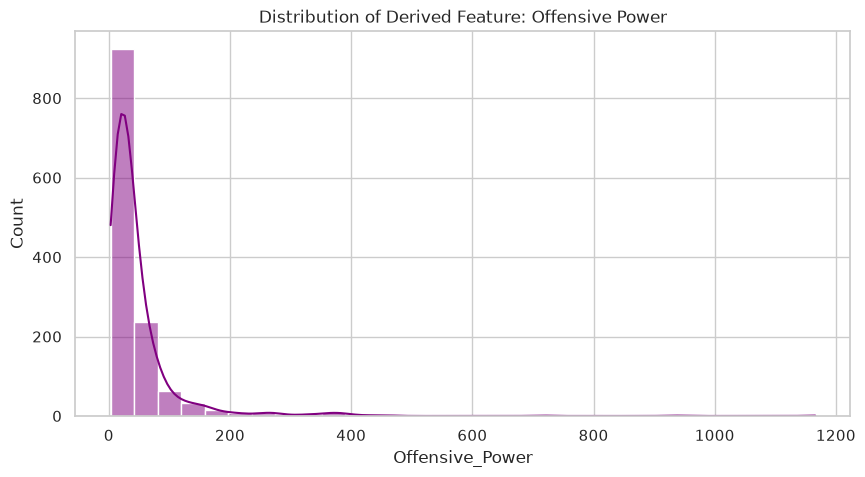

In [13]:
data['Offensive_Power'] = data['Attacks'] * data['Strength'] * data['Damage']

plt.figure(figsize=(10, 5))
sns.histplot(data['Offensive_Power'], bins=30, kde=True, color='purple')
plt.title("Distribution of Derived Feature: Offensive Power")
plt.show()


### Text Feature Engineering: Faction Vocabulary
Factions in Warhammer 40k have highly distinct naming conventions. Orks use words like "Kustom" or "Choppa", while Space Marines use "Plasma" or "Bolter". We will extract these text patterns using NLP.


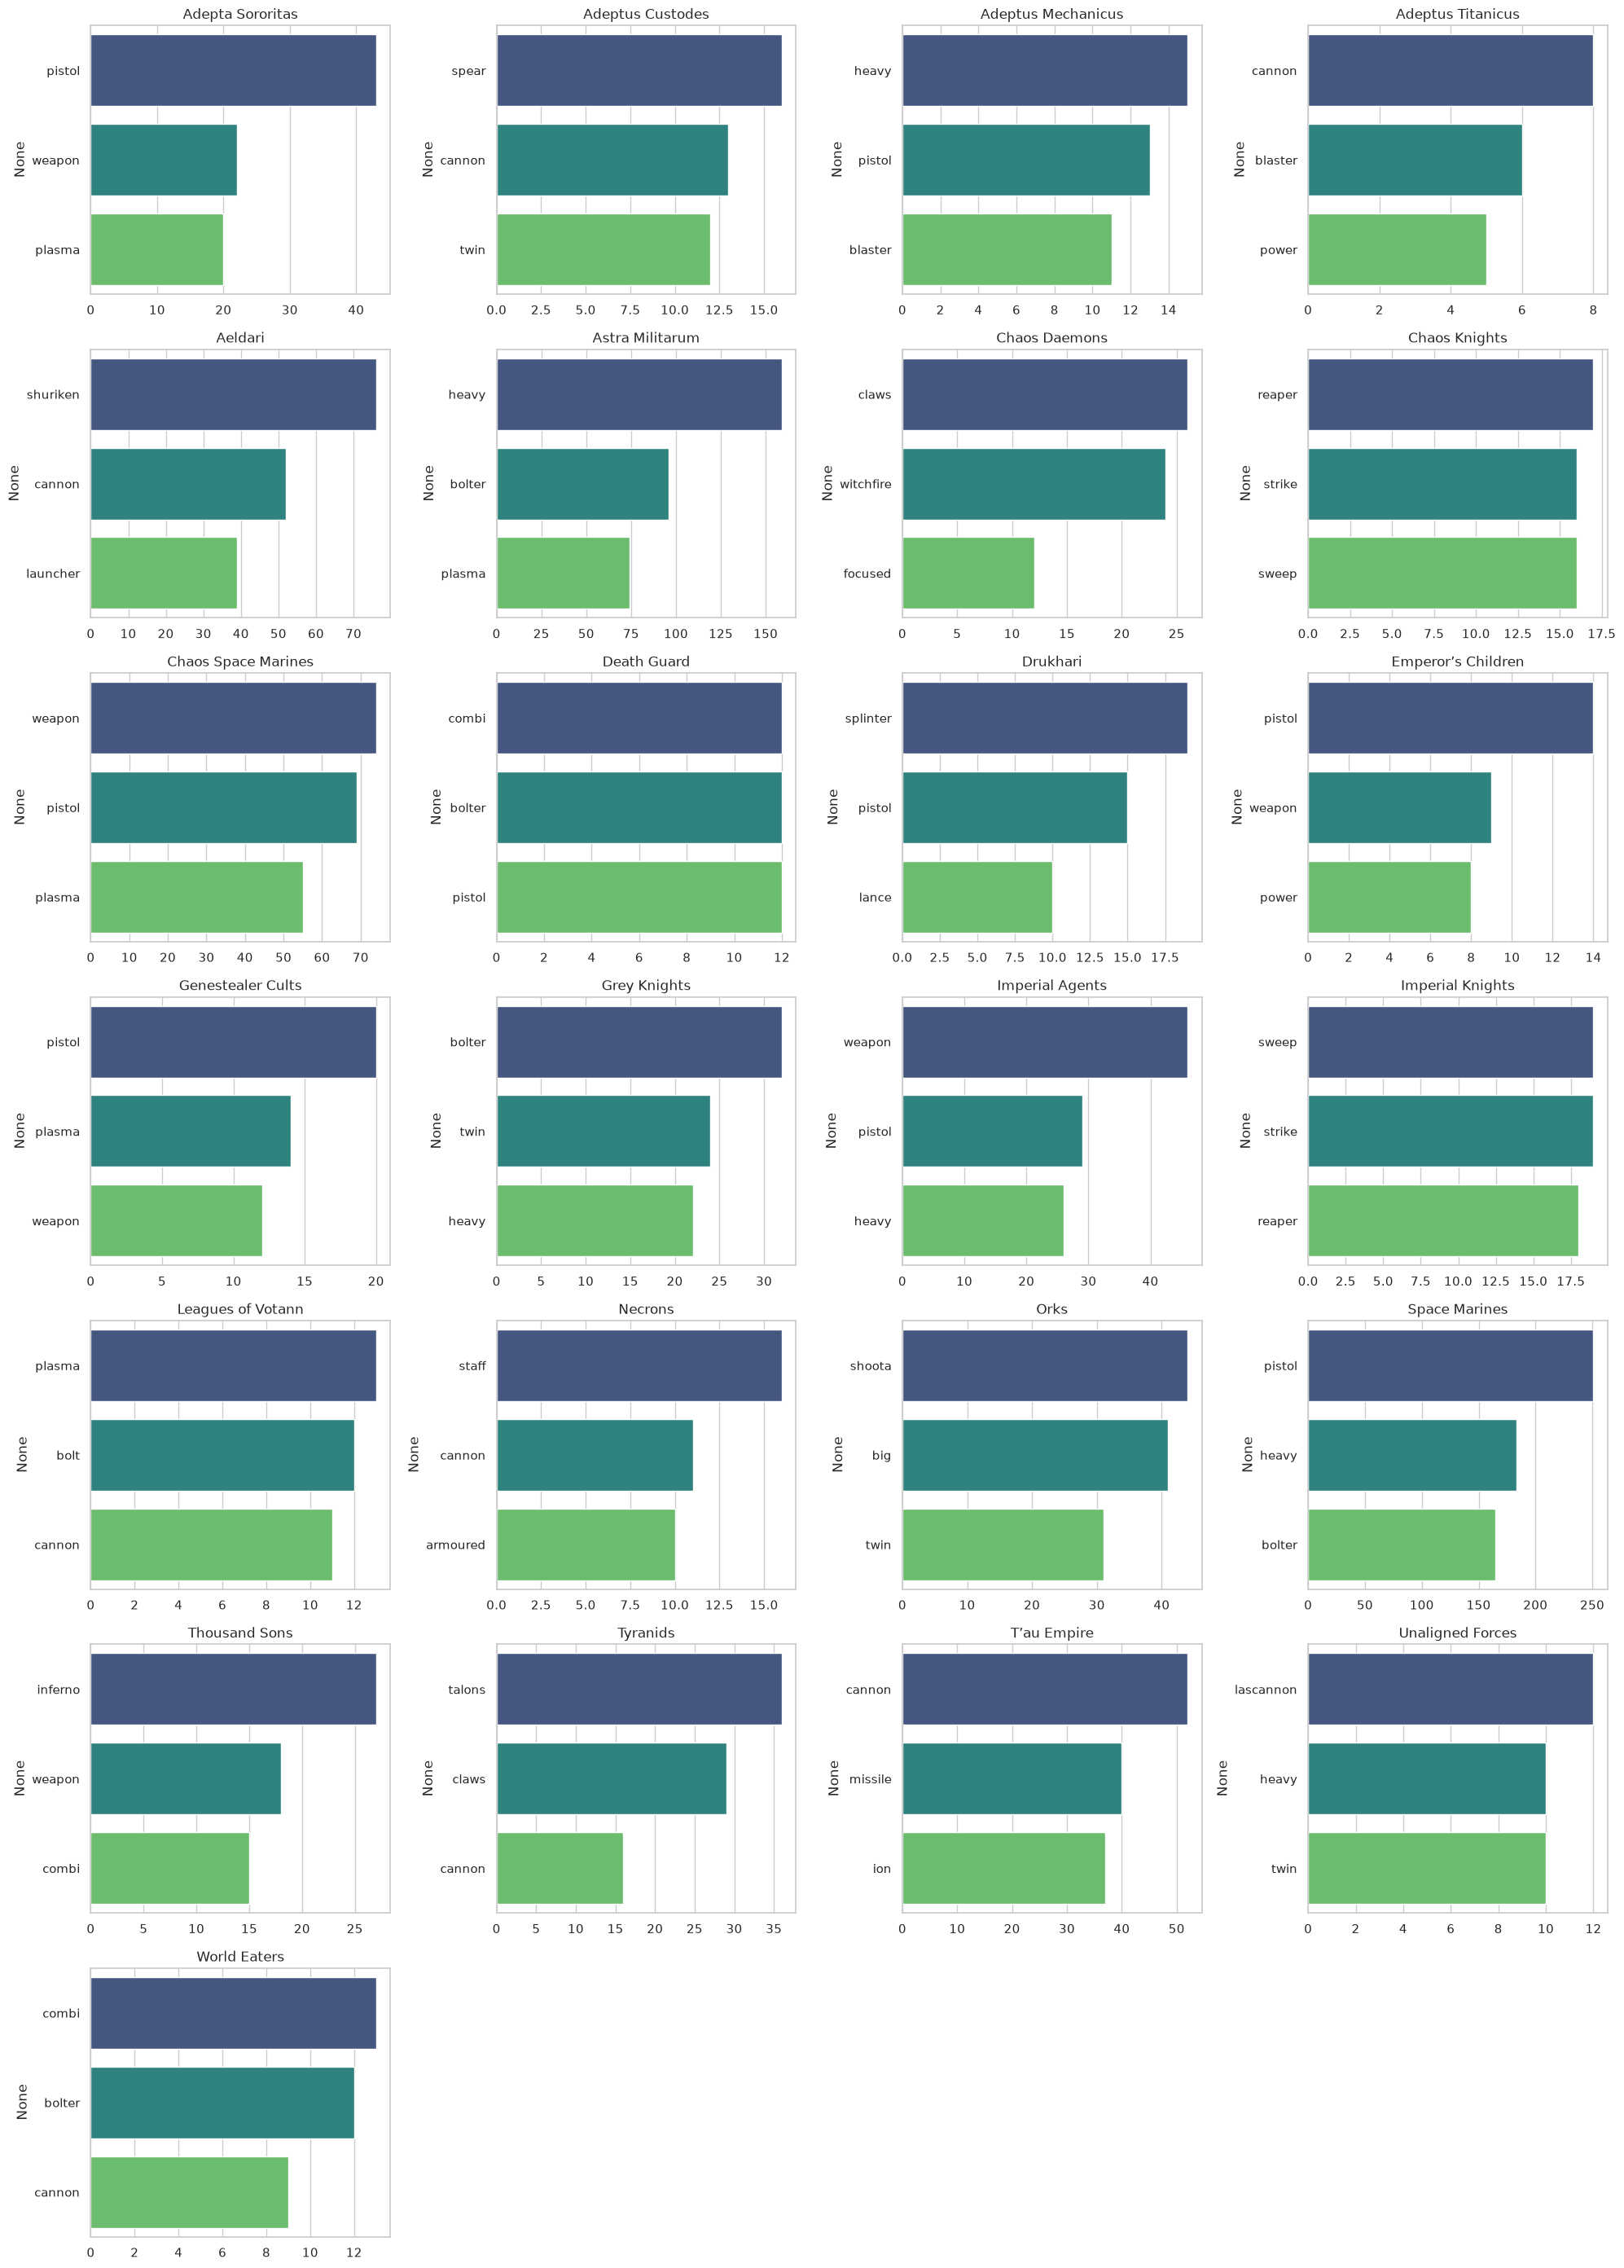

In [14]:
# NLP on Weapon Names for ALL Factions
data['weapon_name'] = data['weapon_name'].fillna('')

# Increase max_features to capture variety across all factions
cv = CountVectorizer(stop_words='english', max_features=100)
words_matrix = cv.fit_transform(data['weapon_name'])
word_counts = pd.DataFrame(words_matrix.toarray(), columns=cv.get_feature_names_out())
word_counts['faction_name'] = data['faction_name']

# Group by faction and get the sum of word counts
faction_words = word_counts.groupby('faction_name').sum()

# Plotting top 3 words for each faction
factions_list = faction_words.index.tolist()
num_factions = len(factions_list)
cols = 4
rows = (num_factions // cols) + (1 if num_factions % cols > 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, faction in enumerate(factions_list):
    row = faction_words.loc[faction]
    top_words = row.sort_values(ascending=False).head(3)
    # Only plot if there are words (count > 0)
    top_words = top_words[top_words > 0]
    
    if not top_words.empty:
        sns.barplot(x=top_words.values, y=top_words.index, ax=axes[i], palette="viridis")
        axes[i].set_title(f'{faction[:25]}')
        axes[i].set_xlabel('')
    else:
        axes[i].set_title(f'{faction[:25]} (No words)')
        axes[i].axis('off')

# Hide any unused subplots
for j in range(len(factions_list), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


The NLP extraction proves highly successful. Words strongly associate with `faction_id`, making text features extremely valuable for prediction.


## 6. Conclusions, Limitations & Roadmap

### Summary of Findings
- **Imbalance**: The dataset is extremely imbalanced towards Space Marines.
- **Cost Balancing**: Stats perfectly scale with cost, indicating a highly balanced game design. 
- **Faction Identity**: Features like Movement, Toughness, and Wargear Specialization (Melee vs Ranged percentages) clearly separate factions like Adeptus Custodes (high toughness, melee) from Astra Militarum (low toughness, ranged).
- **Text Power**: NLP extraction of weapon names proved extremely powerful in identifying faction-specific jargon (e.g., "choppa" for Orks).

### Hypotheses and Decisions for Modeling
- **Hypothesis 1 (Association)**: Weapon vocabulary is the strongest predictor of a faction, even more than numerical stats, due to thematic naming conventions.
- **Hypothesis 2**: Cost efficiency (`Toughness_per_Cost`) can accurately distinguish elite factions from swarm factions.
- **Decision 1**: We must use TF-IDF or CountVectorizer on `weapon_name` and `loadout`.
- **Decision 2**: We must apply class weighting or SMOTE to handle the massive Space Marine overrepresentation.
- **Decision 3**: Missing numeric values in Wargear stats will be imputed with 0, under the assumption that a missing attack stat implies the unit relies on abilities rather than direct combat.

These decisions must be strictly validated during the cross-validation phase of modeling to avoid data leakage.
